## ML&Fintech HW7 Chapter 5 Q8

Name: Alvin B. Lin\
ID: 112652040\
Date: 14/11/2025\
HW #: 7

8.We will now perform cross-validation on a simulated data set.

(a) Generate a simulated data set as follows:\
`rng = np.random.default_rng(1)`\
`x = rng.normal(size=100)`\
`y = x- 2 * x**2 + rng.normal(size=100)`
In this data set, what is n and what is *p*? Write out the model used to generate the data in equation form.

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import random
from sklearn.model_selection import train_test_split

In [21]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x ** 2 + rng.normal(size=100)

---

(b) Create a scatterplot of $X$ against $Y$. Comment on what you find.

Text(0.5, 1.0, 'Scatter plot of y vs x')

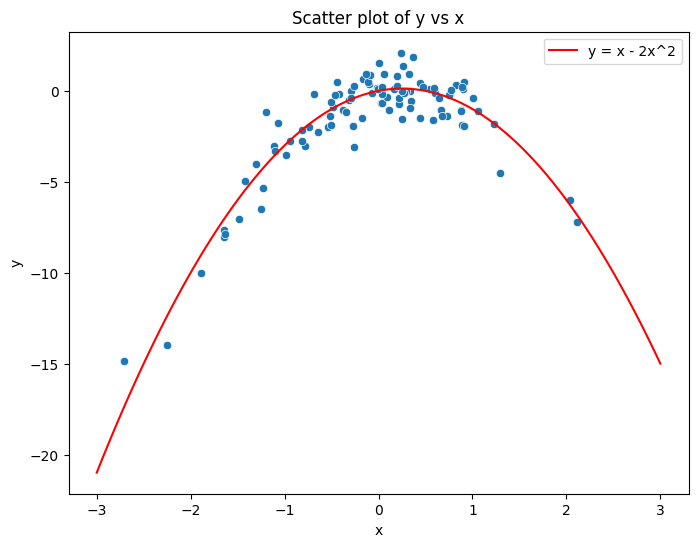

In [22]:
fig = plt.figure(figsize=(8, 6))
# add curve y = x - 2x^2
x_curve = np.linspace(-3, 3, 100)
y_curve = x_curve - 2 * x_curve ** 2
plt.plot(x_curve, y_curve, color='red', label='y = x - 2x^2')
plt.legend()
sns.scatterplot(x=x, y=y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of y vs x")

The $X$ coordinates mainly focus in the centre ($X = 0$), this is beacuse the $X$'s are randomly decided by the normal distribution. This may cause the fitting problem.

---

(c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:\
  i. $Y = \beta_0 + \beta_1X + \varepsilon$\
 ii. $Y = \beta_0 + \beta_1X + \beta_2 X^2+ \varepsilon$\
iii. $Y = \beta_0 + \beta_1X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon$\
 iv. $Y = \beta_0 + \beta_1X + \beta_2 X^2 + \beta_3 x^3 + \beta_4 X^4 + \varepsilon$\
Note you may find it helpful to use the `data.frame()` function to create a single data set containing both X and Y .

In [31]:
df = pd.DataFrame({'x': x, 'x^2': x**2, 'x^3': x**3, 'x^4': x**4, 'y': y})
# I don't understand the purpose of setting random seed in LOOCV, LOOCV is already deterministic!
random.seed(42)

In [32]:
# loocv, treat every point as test set once
n = df.shape[0]
loocv_errors = {}
for degree in range(1, 5):
    squared_errors = []
    for i in range(n):
        train_data = df.drop(index=i)
        test_data = df.iloc[i:i+1]
        X_train = train_data[[f'x^{j}' if j > 1 else 'x' for j in range(1, degree + 1)]].values
        y_train = train_data['y'].values
        X_test = test_data[[f'x^{j}' if j > 1 else 'x' for j in range(1, degree + 1)]].values
        y_test = test_data['y'].values

        # Fit model
        beta_hat = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
        y_pred = X_test @ beta_hat
        squared_errors.append((y_test - y_pred) ** 2)
    loocv_errors[degree] = np.mean(squared_errors)

print("LOOCV Errors for different polynomial degrees:")
for degree, error in loocv_errors.items():
    print(f"Degree {degree}: {error}")


LOOCV Errors for different polynomial degrees:
Degree 1: 8.868921429341826
Degree 2: 1.100250920032015
Degree 3: 1.2791253975060413
Degree 4: 1.3230294199468562


(d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

In [33]:
# Repeat with different random seed, though it should not matter for LOOCV
random.seed(2025)

# loocv, treat every point as test set once
n = df.shape[0]
loocv_errors = {}
for degree in range(1, 5):
    squared_errors = []
    for i in range(n):
        train_data = df.drop(index=i)
        test_data = df.iloc[i:i+1]
        X_train = train_data[[f'x^{j}' if j > 1 else 'x' for j in range(1, degree + 1)]].values
        y_train = train_data['y'].values
        X_test = test_data[[f'x^{j}' if j > 1 else 'x' for j in range(1, degree + 1)]].values
        y_test = test_data['y'].values

        # Fit model
        beta_hat = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
        y_pred = X_test @ beta_hat
        squared_errors.append((y_test - y_pred) ** 2)
    loocv_errors[degree] = np.mean(squared_errors)

print("LOOCV Errors for different polynomial degrees:")
for degree, error in loocv_errors.items():
    print(f"Degree {degree}: {error}")


LOOCV Errors for different polynomial degrees:
Degree 1: 8.868921429341826
Degree 2: 1.100250920032015
Degree 3: 1.2791253975060413
Degree 4: 1.3230294199468562


The result is **identical** to the one got from (c), the reason is simple: LOOCV is **deterministic**, meaning that no randomness involved to the training process. Each points are considered to a split set.

---

(e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

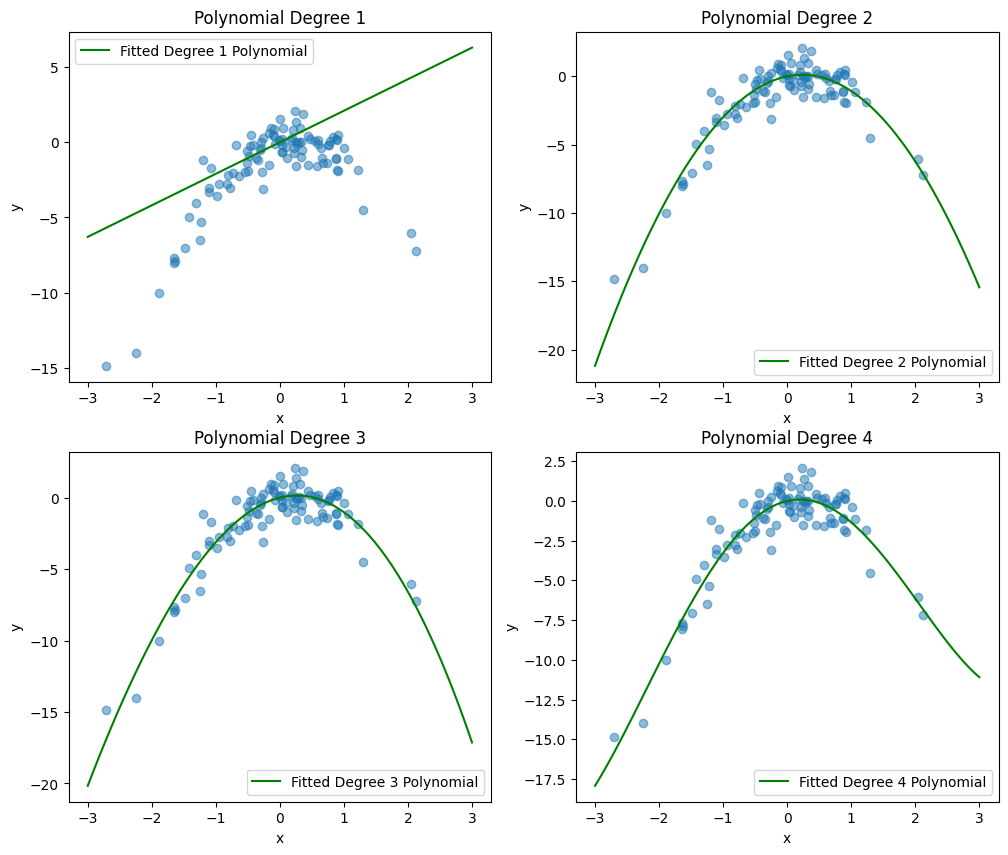

In [34]:
# plot the training result for degree 1 to 4
x_plot = np.linspace(-3, 3, 100)
fig = plt.figure(figsize=(12, 10))
for degree in range(1, 5):
    X_design = np.vstack([x**d for d in range(1, degree + 1)]).T
    beta_hat = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    y_plot = sum(beta_hat[d-1] * x_plot**d for d in range(1, degree + 1))

    plt.subplot(2, 2, degree)
    plt.plot(x_plot, y_plot, label=f'Fitted Degree {degree} Polynomial', color='green')
    plt.scatter(x, y, alpha=0.5)
    plt.title(f'Polynomial Degree {degree}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()

Based on the result in (c), we see that when **degree = 2**, the model has the smallest LOOCV error. The reason is quite simple, the target $Y$ is determined by a **quadratic polynomial** of $X$ plus an error $\varepsilon$.

---

(f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

In [35]:
from statsmodels.api import OLS, add_constant
# Fit polynomial regression models of degree 1 to 4 and display summaries
for degree in range(1, 5):
    X_design = np.vstack([x**d for d in range(1, degree + 1)]).T
    X_design = add_constant(X_design)
    model = OLS(y, X_design).fit()
    print(f"Polynomial Degree {degree} Regression Summary:")
    print(model.summary())

Polynomial Degree 1 Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           1.04e-09
Time:                        10:48:21   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

We can see from the summary that especially indicates that degree 3 term $X^3$ have $p$-value greater than 0.05, meaning that the term is unsignificant to the regression. But for $X^4$ term, which has $p$-value less than 0.05, hence we reject the null hypothesis.